# Explorartory Data Analysis & Intro

## Goals
1. Investigate top-paying roles and skills in the data science industry.
2. Use Python to explore a real-live dataset on job postings.
3. For job-seekers: use these insights to help find the best job opportunities.
4. Create a summary page (via [ReadMe.md](ReadMe.md))

## Questions to answer:
1. What are the most demanded skills for top 3 most popular data roles?
2. How are in-demand skills trending for Data Analysts in India?
3. How well do jobs and skills pay for Data Analysts in India?
4. What is the most Optimal Skills to learn for Data Analysts in India?

# Exploratory Data Analysis for all Data Roles
### Roles to Explore

In [2]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import ast
from datasets import load_dataset
import seaborn as sns

ds = load_dataset("lukebarousse/data_jobs")                                 #loading the dataset
df = ds['train'].to_pandas()                                                #converting to dataframe type
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])               # job_posted_date cleanup

def clean_list(skill_list):
    if pd.notna(skill_list):
        return ast.literal_eval(skill_list)
    
df['job_skills'] = df['job_skills'].apply(clean_list)                       # job_skill cleanup

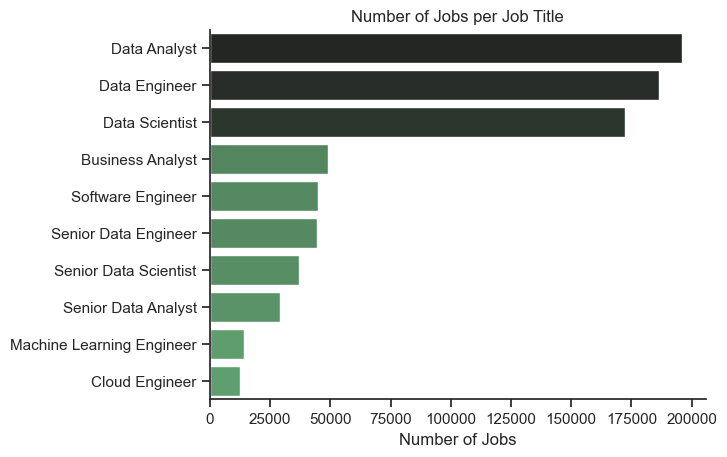

In [4]:
df_plot_jobs = df['job_title_short'].value_counts().to_frame()
sns.set_theme(style = 'ticks')
sns.barplot(data = df_plot_jobs, x = 'count', y = 'job_title_short', hue = 'count', palette = 'dark:g_r', legend = False)
sns.despine()
plt.title('Number of Jobs per Job Title')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

### Countries to explore

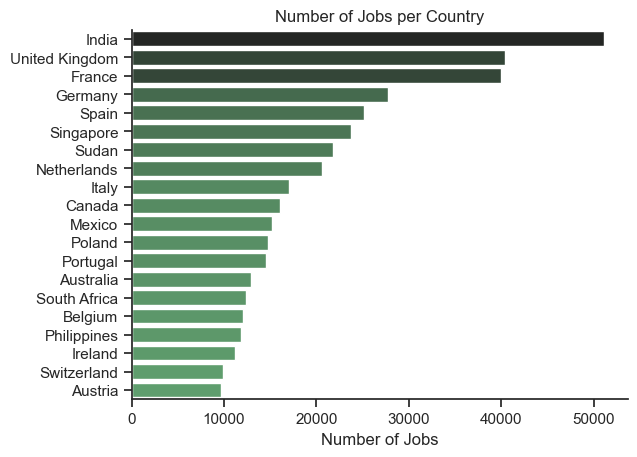

In [96]:
df_plot_countries = df['job_country'].value_counts()[1:].to_frame().head(20)            # excluding USA
sns.set_theme(style = 'ticks')
sns.barplot(data = df_plot_countries, x = 'count', y = 'job_country', hue = 'count', palette = 'dark:g_r', legend = False)
sns.despine()
plt.title("Number of Jobs per Country")
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()


### Companies to explore

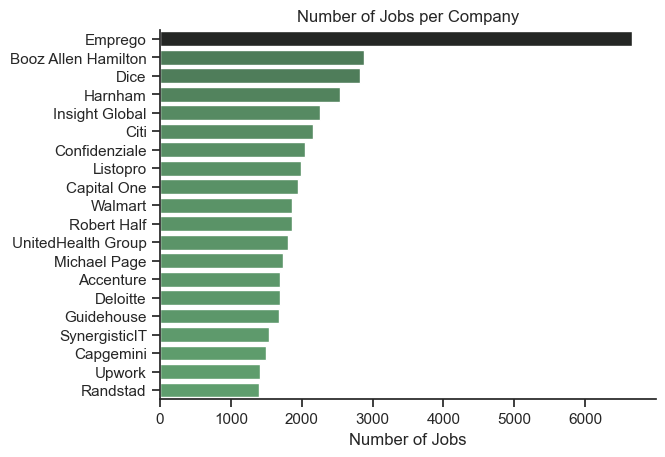

In [95]:
df_plot_companies = df['company_name'].value_counts().to_frame().head(20)
sns.set_theme(style = 'ticks')
sns.barplot(data = df_plot_companies, x = 'count', y = 'company_name', hue = 'count', palette = 'dark:g_r', legend = False)
sns.despine()
plt.title('Number of Jobs per Company')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

### Job Details

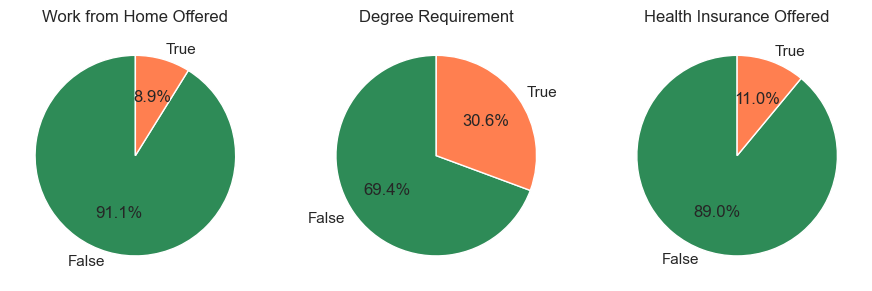

In [34]:
dict_column = {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Degree Requirement',
    'job_health_insurance': 'Health Insurance Offered'
}

fig, ax = plt.subplots(1, 3, figsize=(11, 3.5))

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df[column].value_counts(), labels = ['False', 'True'], startangle = 90, autopct = '%1.1f%%', colors = ['seagreen', 'coral'])
    ax[i].set_title(title)

plt.show()

# EDA for Jobs in India
### Filter for Indian Data Analyst Roles

In [42]:
df_DA_ind = df[(df['job_country'] == 'India') & (df['job_title_short'] == 'Data Analyst')]

### Locations to Explore:

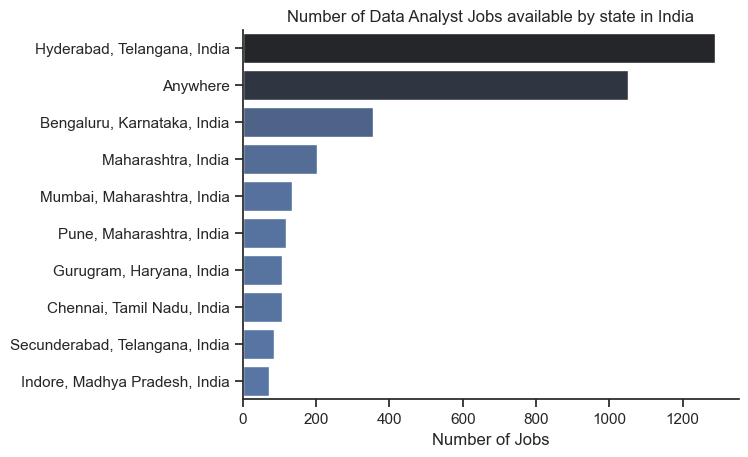

In [ ]:
df_plot_ind = df_DA_ind['job_location'].value_counts()[1:].to_frame().head(10)

sns.set_theme(style = 'ticks')
sns.barplot(data = df_plot_ind, x = 'count', y = 'job_location', hue = 'count', palette = 'dark:b_r', legend = False)
sns.despine()
plt.title('Number of Data Analyst Jobs available by state in India')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

### Job Details

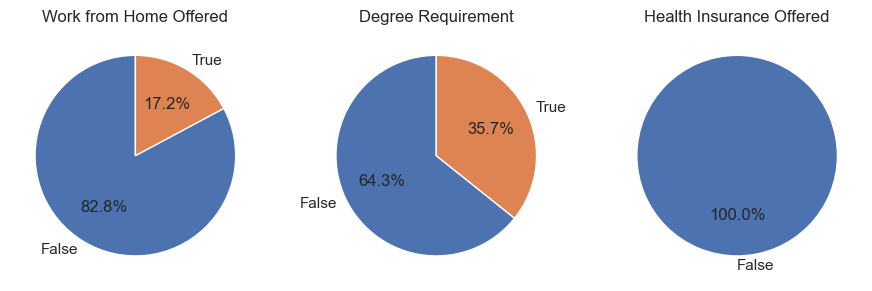

In [93]:
dict_column = {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Degree Requirement',
    'job_health_insurance': 'Health Insurance Offered'
}

fig, ax = plt.subplots(1,3 , figsize = (11,3.5))

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df_DA_ind[column].value_counts(), labels = df_DA_ind[column].value_counts().index, startangle = 90, autopct = '%1.1f%%')
    ax[i].set_title(title)
plt.show()

### Companies to explore

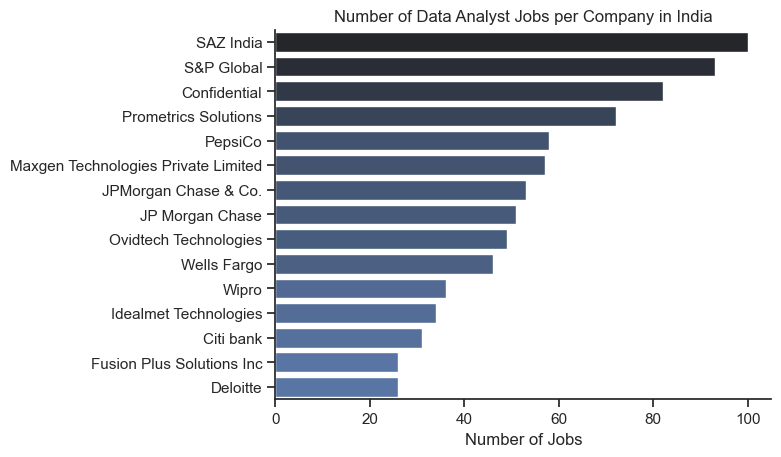

In [88]:
df_plot_companies = df_DA_ind['company_name'].value_counts().to_frame().head(15)

sns.set_theme(style = 'ticks')
sns.barplot(data = df_plot_companies, x = 'count', y = 'company_name', hue = 'count', palette = 'dark:b_r', legend = False)
sns.despine()
plt.title('Number of Data Analyst Jobs per Company in India')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()